# K-Means Clustering on Iris Dataset

This notebook performs K-means clustering on the Iris dataset, evaluates cluster quality, and visualizes the results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('IRIS.csv')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

## Data Scaling

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df[numeric_cols])

print('Scaled data shape:', X.shape)
print('Mean of scaled features (approx.):', np.round(X.mean(axis=0), 3))
print('Std of scaled features (approx.):', np.round(X.std(axis=0), 3))

Scaled data shape: (150, 4)
Mean of scaled features (approx.): [-0. -0.  0. -0.]
Std of scaled features (approx.): [1. 1. 1. 1.]


## Determine Optimal K

In [4]:
max_clusters = 8
inertia = []
silhouette_scores = []

for k in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

results = pd.DataFrame({
    'K': list(range(2, max_clusters + 1)),
    'Inertia': inertia,
    'Silhouette Score': silhouette_scores
})
print(results)

   K     Inertia  Silhouette Score
0  2  223.732006          0.580184
1  3  140.965817          0.458972
2  4  114.617886          0.385285
3  5   91.295445          0.347265
4  6   81.756582          0.340650
5  7   71.319821          0.328832
6  8   62.651767          0.340365


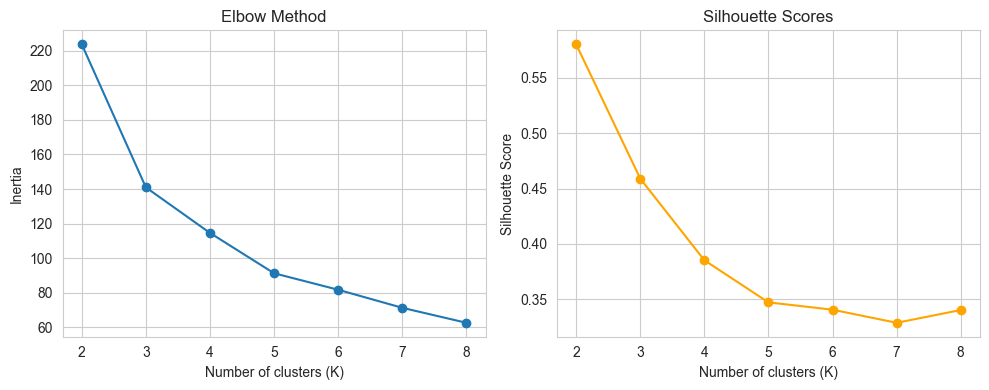

In [5]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(results['K'], results['Inertia'], marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(results['K'], results['Silhouette Score'], marker='o', color='orange')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
best_k_silhouette = np.argmax(silhouette_scores) + 2
inertia_diff = np.diff(inertia)
best_k_elbow = np.argmin(inertia_diff) + 2

print('Best K (Silhouette):', best_k_silhouette)
print('Best K (Elbow approx):', best_k_elbow)

final_k = best_k_silhouette if best_k_silhouette == best_k_elbow else best_k_silhouette
print('Final chosen K:', final_k)

Best K (Silhouette): 2
Best K (Elbow approx): 2
Final chosen K: 2


## Fit K-Means and Inspect Clusters

In [7]:
optimal_k = final_k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

df['cluster'] = cluster_labels
print('Cluster counts:')
print(df['cluster'].value_counts())
print('')
print('Cluster centers (scaled feature space):')
print(np.round(kmeans.cluster_centers_, 3))

Cluster counts:
cluster
0    100
1     50
Name: count, dtype: int64

Cluster centers (scaled feature space):
[[ 0.507 -0.421  0.652  0.628]
 [-1.015  0.842 -1.305 -1.255]]


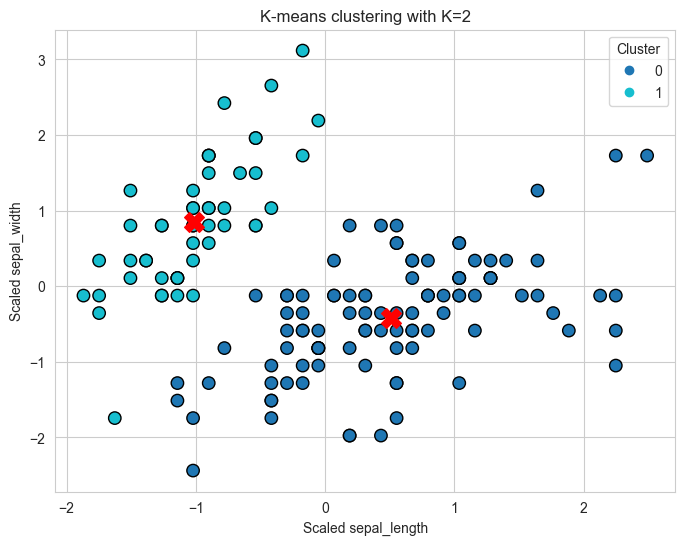

In [8]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='tab10', s=80, edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='X', label='Centers')
plt.xlabel('Scaled ' + numeric_cols[0])
plt.ylabel('Scaled ' + numeric_cols[1])
plt.title(f'K-means clustering with K={optimal_k}')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_10584\1268970658.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=df, palette='tab10')


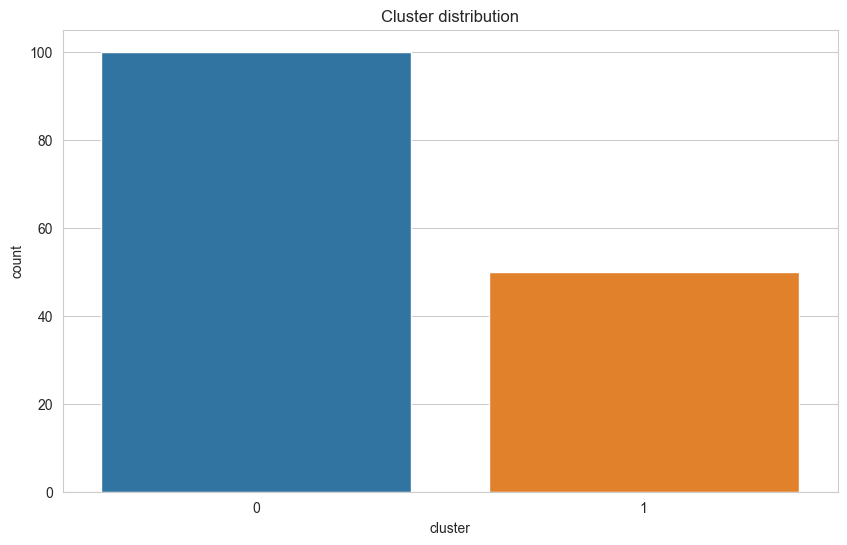

In [9]:
sns.countplot(x='cluster', data=df, palette='tab10')
plt.title('Cluster distribution')
plt.show()